In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "KAN_variants"))
from ChebyKANLayer import ChebyKAN
from efficientKAN import KAN
from fastkan import FastKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "code"))
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 1.5]

In [3]:
model = KAN([2, 7, 7, 2])
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 7.5, 0.01)

100%|██████████| 3000/3000 [13:10:53<00:00, 15.82s/it]  


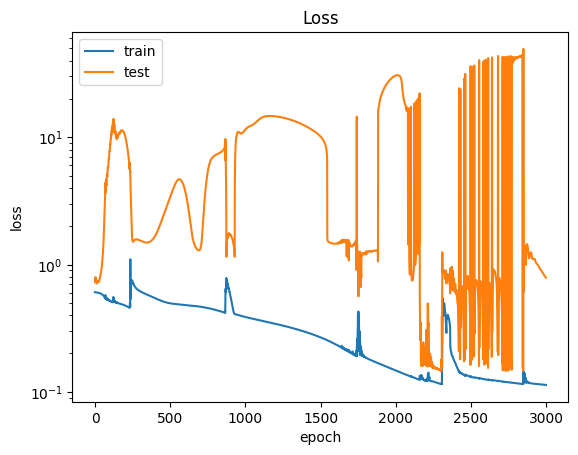

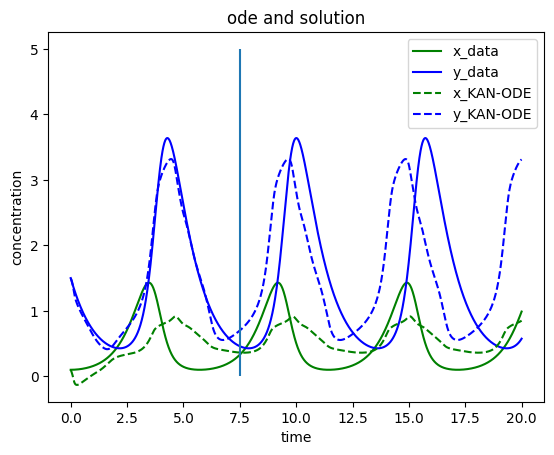

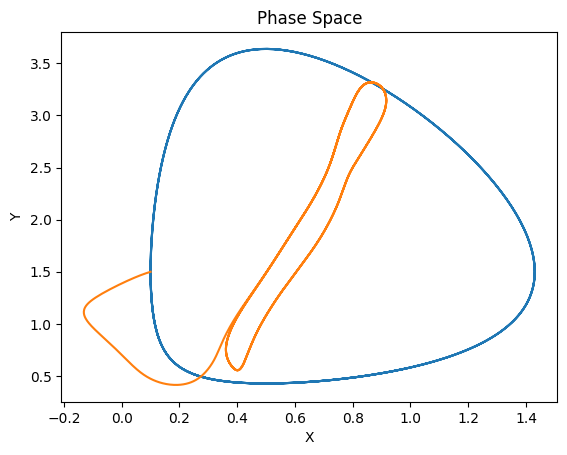

In [4]:
saveDirectory = os.path.join(module_path, "savedModels", "EFFKAN2")
if not os.path.isdir(saveDirectory):
    os.makedirs(saveDirectory)

kanODE.train(-1, solverMethod="rk4", saveDirectory=saveDirectory, saveCooldown=200, maxEpochs=3000)
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

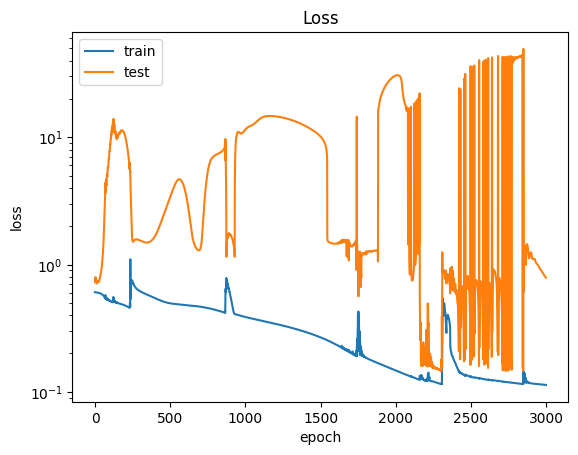

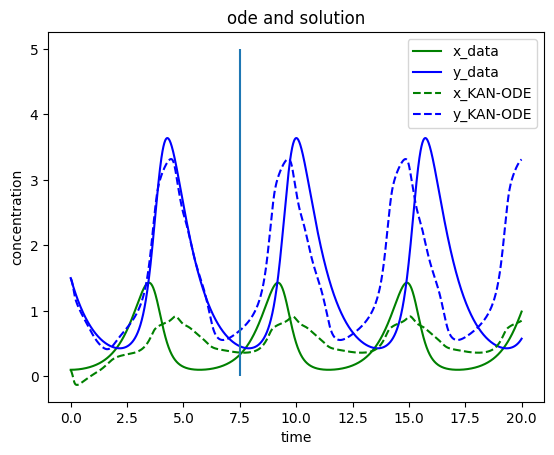

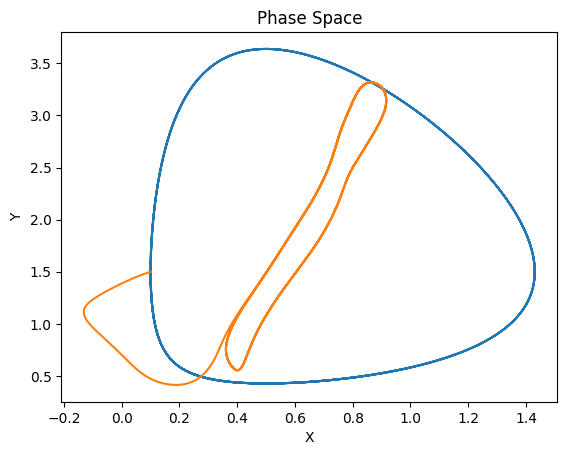

In [ ]:
kanODE.train(-1, solverMethod="rk4", saveDirectory=saveDirectory, saveCooldown=200, maxEpochs=3000)
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])